# Phase 1 — So sánh Embedding Model

**Dự án:** Vietnamese Legal RAG  
**Mục tiêu notebook:** Đánh giá và so sánh hai embedding model để chọn ra model tốt nhất cho hệ thống retrieval:

1. `keepitreal/vietnamese-sbert` — Chuyên biệt tiếng Việt (~400MB)
2. `paraphrase-multilingual-MiniLM-L12-v2` — Đa ngôn ngữ, nhẹ hơn (~120MB)

**Nội dung notebook:**
- [1. Thiết lập môi trường](#1)
- [2. Minh họa Cosine Similarity từ numpy](#2)
- [3. Chuẩn bị dữ liệu test](#3)
- [4. So sánh hai model](#4)
- [5. Kết luận & Lựa chọn](#5)

<a id='1'></a>
## 1. Thiết lập môi trường

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['font.size'] = 11

# Đặt working directory về thư mục gốc của project
sys.path.append('..')

CHUNK_STORE_PATH = Path('../data/processed/chunk_store.jsonl')
print("Môi trường sẵn sàng ✓")

Môi trường sẵn sàng ✓


<a id='2'></a>
## 2. Minh họa Cosine Similarity từ numpy

Trước khi dùng FAISS, mình tự implement cosine similarity để hiểu cơ chế bên dưới:

**Cosine Similarity** = dot product của hai vector đã được chuẩn hóa (normalize).

$$\text{cosine\_sim}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

Sau normalize: $\|A\| = \|B\| = 1$, nên **cosine\_sim = dot product**.

In [2]:
# ---------------------------------------------------------------
# Implement cosine similarity thuần numpy
# ---------------------------------------------------------------

def cosine_similarity_numpy(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    """
    Tính cosine similarity giữa hai vector.
    Công thức: cos(θ) = (A · B) / (‖A‖ × ‖B‖)
    """
    dot_product = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(dot_product / (norm_a * norm_b))


def normalize(vec: np.ndarray) -> np.ndarray:
    """Chuẩn hóa vector về độ dài = 1."""
    norm = np.linalg.norm(vec)
    if norm == 0:
        return vec
    return vec / norm


# --- Demo với vector giả ---
v1 = np.array([1.0, 0.0, 0.0])   # vector X
v2 = np.array([0.0, 1.0, 0.0])   # vector Y (vuông góc)
v3 = np.array([1.0, 1.0, 0.0])   # vector nằm giữa X và Y
v4 = np.array([2.0, 0.0, 0.0])   # cùng hướng X nhưng độ dài khác

print("=" * 55)
print("DEMO: Cosine Similarity thủ công bằng numpy")
print("=" * 55)
print(f"v1 = {v1}  (hướng X)")
print(f"v2 = {v2}  (hướng Y, vuông góc với v1)")
print(f"v3 = {v3}  (chéo 45° giữa X và Y)")
print(f"v4 = {v4}  (cùng hướng X, dài gấp đôi v1)")
print()
print(f"cos(v1, v2) = {cosine_similarity_numpy(v1, v2):.4f}  → vuông góc, không liên quan")
print(f"cos(v1, v3) = {cosine_similarity_numpy(v1, v3):.4f}  → góc 45°, khá liên quan")
print(f"cos(v1, v4) = {cosine_similarity_numpy(v1, v4):.4f}  → cùng hướng, hoàn toàn giống nhau")
print()

# Kiểm tra: sau normalize, dot product = cosine similarity
v1_norm = normalize(v1)
v3_norm = normalize(v3)
dot_after_norm = float(np.dot(v1_norm, v3_norm))
cosine_direct = cosine_similarity_numpy(v1, v3)
print(f"Kiểm tra: dot_product(normalize(v1), normalize(v3)) = {dot_after_norm:.4f}")
print(f"          cosine_similarity(v1, v3)                 = {cosine_direct:.4f}")
print(f"          → Kết quả bằng nhau: {abs(dot_after_norm - cosine_direct) < 1e-9} ✓")
print()
print("Kết luận: FAISS IndexFlatIP (inner product) trên vector đã normalize")
print("          = Cosine similarity. Đây là lý do embedder.py normalize trước khi index.")

DEMO: Cosine Similarity thủ công bằng numpy
v1 = [1. 0. 0.]  (hướng X)
v2 = [0. 1. 0.]  (hướng Y, vuông góc với v1)
v3 = [1. 1. 0.]  (chéo 45° giữa X và Y)
v4 = [2. 0. 0.]  (cùng hướng X, dài gấp đôi v1)

cos(v1, v2) = 0.0000  → vuông góc, không liên quan
cos(v1, v3) = 0.7071  → góc 45°, khá liên quan
cos(v1, v4) = 1.0000  → cùng hướng, hoàn toàn giống nhau

Kiểm tra: dot_product(normalize(v1), normalize(v3)) = 0.7071
          cosine_similarity(v1, v3)                 = 0.7071
          → Kết quả bằng nhau: True ✓

Kết luận: FAISS IndexFlatIP (inner product) trên vector đã normalize
          = Cosine similarity. Đây là lý do embedder.py normalize trước khi index.


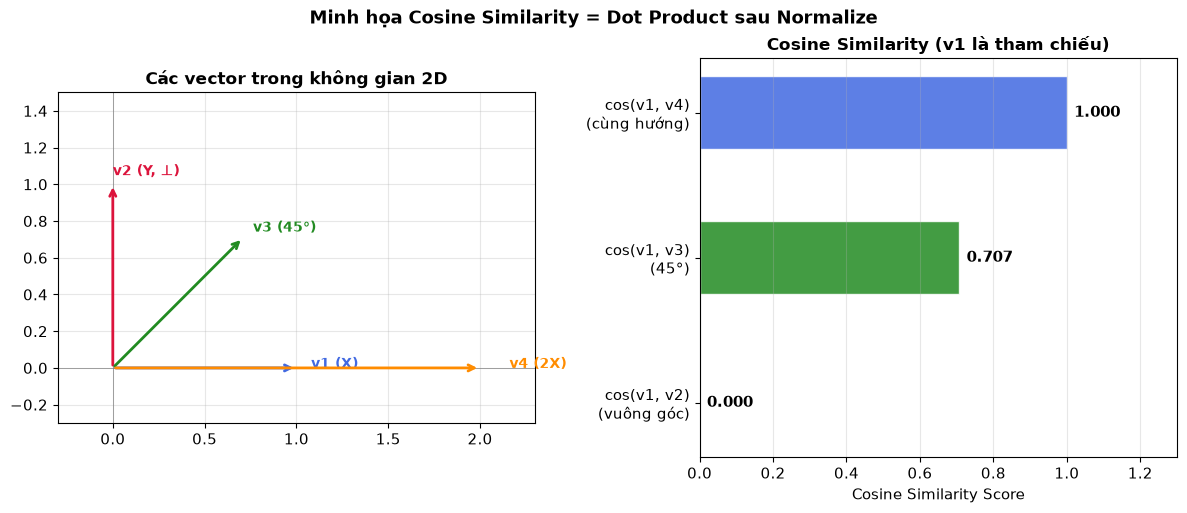


Đã lưu biểu đồ → docs/cosine_similarity_demo.png


In [3]:
# Minh họa bằng biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Các vector trong không gian 2D
ax1 = axes[0]
origin = np.array([0, 0])
vectors = {
    'v1 (X)': (np.array([1, 0]), 'royalblue'),
    'v2 (Y, ⊥)': (np.array([0, 1]), 'crimson'),
    'v3 (45°)': (np.array([1, 1]) / np.linalg.norm([1, 1]), 'forestgreen'),
    'v4 (2X)': (np.array([2, 0]), 'darkorange'),
}
for label, (v, color) in vectors.items():
    ax1.annotate('', xy=v, xytext=origin,
                 arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax1.text(v[0]*1.08, v[1]*1.05, label, fontsize=10, color=color, fontweight='bold')

ax1.set_xlim(-0.3, 2.3)
ax1.set_ylim(-0.3, 1.5)
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.axvline(0, color='gray', linewidth=0.5)
ax1.set_title('Các vector trong không gian 2D', fontsize=12, fontweight='bold')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Biểu đồ 2: Cosine similarity bar chart
ax2 = axes[1]
pairs = ['cos(v1, v2)\n(vuông góc)', 'cos(v1, v3)\n(45°)', 'cos(v1, v4)\n(cùng hướng)']
scores = [
    cosine_similarity_numpy(np.array([1,0]), np.array([0,1])),
    cosine_similarity_numpy(np.array([1,0]), np.array([1,1])),
    cosine_similarity_numpy(np.array([1,0]), np.array([2,0])),
]
colors = ['crimson', 'forestgreen', 'royalblue']
bars = ax2.barh(pairs, scores, color=colors, alpha=0.85, edgecolor='white', height=0.5)
for bar, score in zip(bars, scores):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=11, fontweight='bold')
ax2.set_xlim(0, 1.3)
ax2.set_xlabel('Cosine Similarity Score', fontsize=11)
ax2.set_title('Cosine Similarity (v1 là tham chiếu)', fontsize=12, fontweight='bold')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.suptitle('Minh họa Cosine Similarity = Dot Product sau Normalize', 
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig('../docs/cosine_similarity_demo.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nĐã lưu biểu đồ → docs/cosine_similarity_demo.png")

<a id='3'></a>
## 3. Chuẩn bị dữ liệu test

Xây dựng bộ 10 cặp query/câu hỏi thủ công để kiểm tra chất lượng retrieval của từng model.

In [4]:
# Load một mẫu chunk để test
chunks = []
with open(CHUNK_STORE_PATH, encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 500:  # lấy 500 chunks đầu để demo nhanh
            break
        chunks.append(json.loads(line))

print(f"Đã load {len(chunks)} chunks từ chunk_store.jsonl")
print(f"Sample chunk:")
sample = chunks[10]
print(f"  chunk_id:    {sample['chunk_id']}")
print(f"  article_ref: {sample['article_ref']}")
print(f"  char_len:    {sample['char_len']}")
print(f"  text[:150]:  {sample['text'][:150]}...")

Đã load 500 chunks từ chunk_store.jsonl
Sample chunk:
  chunk_id:    100_chunk_0001
  article_ref: Điều 2
  char_len:    183
  text[:150]:  Điều 2: Ban Kinh tế Chính phủ có nhiệm vụ nghiên cứu, khởi thảo để đệ trình Chính phủ những đề án về chính sách chương trình, kế họach kinh tế hoặc nh...


In [5]:
# 10 câu test thủ công: query → chunk_id mong đợi (hoặc text gợi ý)
# Mỗi query được kiểm tra xem model có trả về chunk liên quan không
TEST_QUERIES = [
    "điều kiện để ký hợp đồng lao động",
    "mức lương tối thiểu vùng năm hiện hành",
    "thủ tục đăng ký thành lập doanh nghiệp",
    "quyền và nghĩa vụ của người lao động",
    "thời gian làm thêm giờ tối đa trong ngày",
    "chế độ bảo hiểm xã hội bắt buộc",
    "trình tự thủ tục xử lý kỷ luật lao động",
    "điều kiện được hưởng trợ cấp thất nghiệp",
    "quy định về thời gian thử việc",
    "mức phạt vi phạm hành chính về lao động",
]

print(f"Chuẩn bị {len(TEST_QUERIES)} câu hỏi test thủ công:")
for i, q in enumerate(TEST_QUERIES, 1):
    print(f"  {i:2d}. {q}")

Chuẩn bị 10 câu hỏi test thủ công:
   1. điều kiện để ký hợp đồng lao động
   2. mức lương tối thiểu vùng năm hiện hành
   3. thủ tục đăng ký thành lập doanh nghiệp
   4. quyền và nghĩa vụ của người lao động
   5. thời gian làm thêm giờ tối đa trong ngày
   6. chế độ bảo hiểm xã hội bắt buộc
   7. trình tự thủ tục xử lý kỷ luật lao động
   8. điều kiện được hưởng trợ cấp thất nghiệp
   9. quy định về thời gian thử việc
  10. mức phạt vi phạm hành chính về lao động


<a id='4'></a>
## 4. So sánh hai Model

### 4.1. Tốc độ Encode & Kích thước Model

In [6]:
from sentence_transformers import SentenceTransformer

MODELS = {
    "vietnamese-sbert": "keepitreal/vietnamese-sbert",
    "MiniLM-L12": "paraphrase-multilingual-MiniLM-L12-v2",
}

chunk_texts = [c['text'] for c in chunks]
results = {}

for model_short, model_name in MODELS.items():
    print(f"\n{'='*55}")
    print(f"Loading: {model_name}")
    t_load = time.time()
    model = SentenceTransformer(model_name)
    load_time = time.time() - t_load
    
    # Đếm tham số model
    n_params = sum(p.numel() for p in model._modules['0'].auto_model.parameters())
    
    # Encode batch
    t_encode = time.time()
    embeddings = model.encode(chunk_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    encode_time = time.time() - t_encode
    
    embedding_dim = embeddings.shape[1]
    
    results[model_short] = {
        'model': model,
        'model_name': model_name,
        'load_time': load_time,
        'encode_time': encode_time,
        'embeddings': embeddings,
        'dim': embedding_dim,
        'n_params': n_params,
        'chunks_per_sec': len(chunks) / encode_time,
    }
    
    print(f"  ✓ Load time:      {load_time:.1f}s")
    print(f"  ✓ Encode time:    {encode_time:.1f}s ({len(chunks)/encode_time:.0f} chunks/s)")
    print(f"  ✓ Embedding dim:  {embedding_dim}")
    print(f"  ✓ Model params:   {n_params/1e6:.1f}M")

print("\n✓ Encode xong cả hai model!")

D:\Documents University\Project\legaldoc-qa-vn\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading: keepitreal/vietnamese-sbert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 28124.08it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

...

Batches:  88%|████████▊ | 14/16 [00:11<00:01,  1.35it/s]

Batches:  94%|█████████▍| 15/16 [00:11<00:00,  1.60it/s]

Batches: 100%|██████████| 16/16 [00:11<00:00,  2.08it/s]

Batches: 100%|██████████| 16/16 [00:11<00:00,  1.36it/s]

  ✓ Load time:      9.1s
  ✓ Encode time:    11.8s (43 chunks/s)
  ✓ Embedding dim:  384
  ✓ Model params:   117.7M

✓ Encode xong cả hai model!


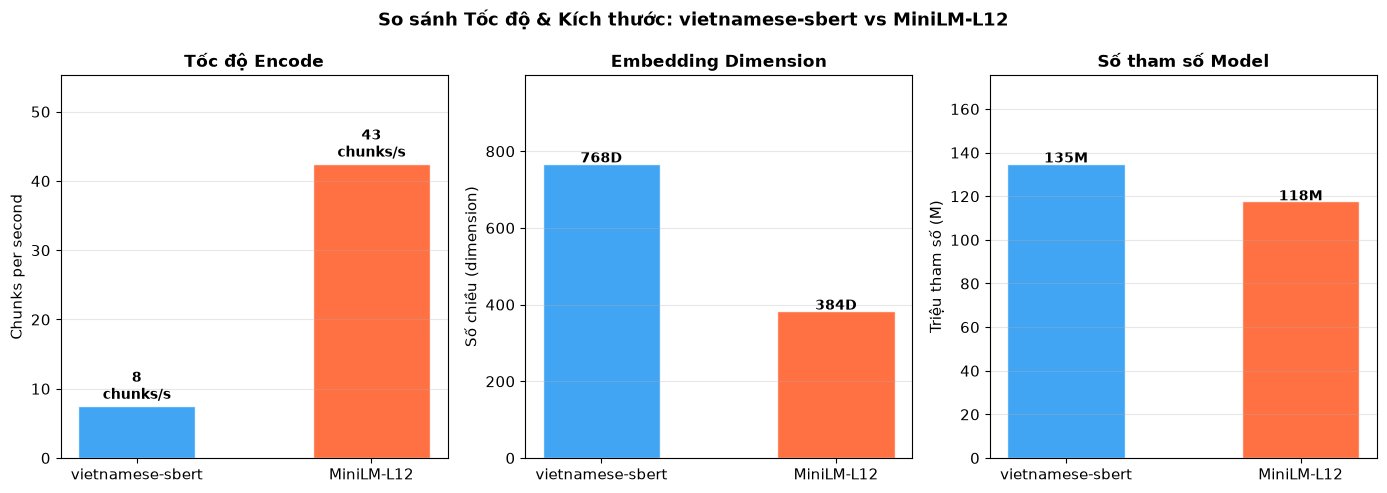

Đã lưu biểu đồ → docs/embedding_speed_comparison.png


In [7]:
# Biểu đồ so sánh tốc độ & kích thước
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

model_labels = list(results.keys())
colors = ['#2196F3', '#FF5722']

# Tốc độ encode
ax1 = axes[0]
speeds = [results[m]['chunks_per_sec'] for m in model_labels]
bars = ax1.bar(model_labels, speeds, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, speeds):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}\nchunks/s', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Tốc độ Encode', fontsize=12, fontweight='bold')
ax1.set_ylabel('Chunks per second')
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim(0, max(speeds) * 1.3)

# Kích thước embedding
ax2 = axes[1]
dims = [results[m]['dim'] for m in model_labels]
bars = ax2.bar(model_labels, dims, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, dims):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{val}D', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Embedding Dimension', fontsize=12, fontweight='bold')
ax2.set_ylabel('Số chiều (dimension)')
ax2.grid(True, axis='y', alpha=0.3)
ax2.set_ylim(0, max(dims) * 1.3)

# Số tham số model
ax3 = axes[2]
params = [results[m]['n_params']/1e6 for m in model_labels]
bars = ax3.bar(model_labels, params, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, params):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}M', ha='center', fontsize=10, fontweight='bold')
ax3.set_title('Số tham số Model', fontsize=12, fontweight='bold')
ax3.set_ylabel('Triệu tham số (M)')
ax3.grid(True, axis='y', alpha=0.3)
ax3.set_ylim(0, max(params) * 1.3)

plt.suptitle('So sánh Tốc độ & Kích thước: vietnamese-sbert vs MiniLM-L12',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/embedding_speed_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ → docs/embedding_speed_comparison.png")

### 4.2. Chất lượng Retrieval: Top-5 cho 10 câu test

In [8]:
# Hàm tìm kiếm nearest-neighbor thuần numpy (không dùng FAISS)
def search_cosine(query: str, model, embeddings: np.ndarray, chunk_texts: list, top_k=5):
    """Tìm top_k chunk gần nhất với query bằng cosine similarity."""
    # Encode query
    q_emb = model.encode([query], convert_to_numpy=True)[0]
    q_norm = normalize(q_emb)
    
    # Normalize tất cả embeddings
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    emb_norm = embeddings / norms
    
    # Dot product = cosine similarity (sau normalize)
    scores = emb_norm @ q_norm  # shape (N,)
    
    # Top-k
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(i, float(scores[i]), chunk_texts[i]) for i in top_indices]


print("Chạy retrieval thủ công (cosine similarity từ numpy) cho 10 câu test...\n")

retrieval_results = {m: [] for m in results}

for q_idx, query in enumerate(TEST_QUERIES):
    print(f"[{q_idx+1:2d}] Query: '{query}'")
    for model_short in results:
        model = results[model_short]['model']
        embeddings = results[model_short]['embeddings']
        top5 = search_cosine(query, model, embeddings, chunk_texts, top_k=5)
        retrieval_results[model_short].append(top5)
        top1_score = top5[0][1]
        top1_text = top5[0][2][:80]
        print(f"       [{model_short}] score={top1_score:.3f} | {top1_text}...")
    print()

Chạy retrieval thủ công (cosine similarity từ numpy) cho 10 câu test...

[ 1] Query: 'điều kiện để ký hợp đồng lao động'
       [vietnamese-sbert] score=0.459 | Điều 1. Ban hành kèm theo quyết định này Quy định phối hợp giữa các cơ quan chức...
       [MiniLM-L12] score=0.627 | Điều 1. Nay ban hành kèm theo Quyết định này Quy định về tuyển dụng, chuyển công...

[ 2] Query: 'mức lương tối thiểu vùng năm hiện hành'
       [vietnamese-sbert] score=0.539 | Điều 20. Chế độ, chính sách đối với người hướng dẫn tập sự Người được phân công ...
       [MiniLM-L12] score=0.606 | Điều 1. Quy định mức trợ cấp ngày công lao động đối với lực lượng dân quân thuộc...

[ 3] Query: 'thủ tục đăng ký thành lập doanh nghiệp'
       [vietnamese-sbert] score=0.589 | Điều 5. Nội dung thông tin doanh nghiệp 1. Thông tin đăng ký doanh nghiệp, bao g...


       [MiniLM-L12] score=0.676 | Điều 7. Trách nhiệm của Sở Kế họach và Đầu tư 1. Khi cấp giấy chứng nhận đăng ký...

[ 4] Query: 'quyền và nghĩa vụ của người lao động'
       [vietnamese-sbert] score=0.458 | Điều 5. Trách nhiệm của Ban quản lý các khu công nghiệp và chế xuất Hà Nội Thực ...
       [MiniLM-L12] score=0.642 | b- Để thực hiện quyền hạn và trách nhiệm quy định tại Điều 9 Quy chế và phần IV ...

[ 5] Query: 'thời gian làm thêm giờ tối đa trong ngày'
       [vietnamese-sbert] score=0.361 | Điều 20. Chế độ, chính sách đối với người hướng dẫn tập sự Người được phân công ...
       [MiniLM-L12] score=0.489 | Điều 28. Tập sự Người được tuyển dụng vào công chức cấp xã phải qua thời gian tậ...

[ 6] Query: 'chế độ bảo hiểm xã hội bắt buộc'
       [vietnamese-sbert] score=0.370 | Điều 24. Các cơ quan, tổ chức và cá nhân vi phạm Quy định tuyển dụng công chức c...


       [MiniLM-L12] score=0.424 | Điều 1. Thông qua Đề án nâng cao chất lượng, hiệu quả bảo vệ an ninh trật tự của...

[ 7] Query: 'trình tự thủ tục xử lý kỷ luật lao động'
       [vietnamese-sbert] score=0.544 | Điều 5. Trách nhiệm của Ban quản lý các khu công nghiệp và chế xuất Hà Nội Thực ...
       [MiniLM-L12] score=0.618 | Điều 2. -Ở tỉnh nào xét ra quan hệ nhiều về phương diện lao động sẽ đặt một Ty L...

[ 8] Query: 'điều kiện được hưởng trợ cấp thất nghiệp'
       [vietnamese-sbert] score=0.492 | Điều 11. Quyền và nghĩa vụ của tổ chức, cá nhân thực hiện bảo dưỡng thường xuyên...
       [MiniLM-L12] score=0.528 | Nhằm đảm bảo cho người lao động tìm kiếm lại việc làm tại Việt Nam sau khi hòan ...

[ 9] Query: 'quy định về thời gian thử việc'
       [vietnamese-sbert] score=0.564 | Điều 28. Tập sự Người được tuyển dụng vào công chức cấp xã phải qua thời gian tậ...
       [MiniLM-L12] score=0.775 | Điều 26. Thời hạn ra quyết định tuyển dụng và nhận việc 1. Trong thời hạn 15 ngà...

       [vietnamese-sbert] score=0.429 | Điều 3. Nội dung và cơ chế phối hợp 1. Theo dõi, thống kê, tổng hợp, phân tích t...
       [MiniLM-L12] score=0.591 | Điều 24. Các cơ quan, tổ chức và cá nhân vi phạm Quy định tuyển dụng công chức c...



In [9]:
# So sánh top-1 score trung bình của cả 2 model
avg_top1_scores = {}
for model_short in results:
    top1_scores = [retrieval_results[model_short][q][0][1] for q in range(len(TEST_QUERIES))]
    avg_top1_scores[model_short] = np.mean(top1_scores)

print("Điểm cosine similarity trung bình (top-1) trên 10 câu test:")
for m, score in avg_top1_scores.items():
    print(f"  {m}: {score:.4f}")

Điểm cosine similarity trung bình (top-1) trên 10 câu test:
  vietnamese-sbert: 0.4806
  MiniLM-L12: 0.5976


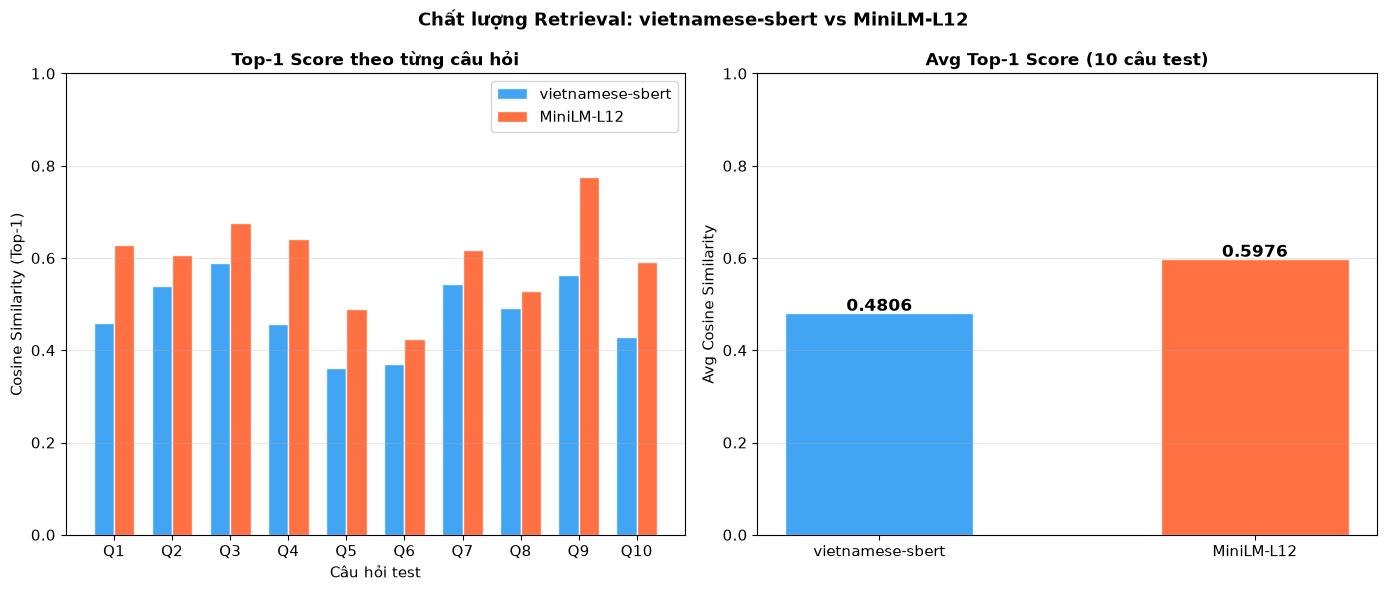

Đã lưu biểu đồ → docs/embedding_quality_comparison.png


In [10]:
# Biểu đồ so sánh chất lượng retrieval
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

query_short = [f"Q{i+1}" for i in range(len(TEST_QUERIES))]
x = np.arange(len(TEST_QUERIES))
width = 0.35

# Biểu đồ 1: Top-1 score theo từng câu hỏi
ax1 = axes[0]
for i, (model_short, color) in enumerate(zip(results.keys(), ['#2196F3', '#FF5722'])):
    top1_scores = [retrieval_results[model_short][q][0][1] for q in range(len(TEST_QUERIES))]
    ax1.bar(x + i*width - width/2, top1_scores, width, label=model_short, 
            color=color, alpha=0.85, edgecolor='white')

ax1.set_xlabel('Câu hỏi test')
ax1.set_ylabel('Cosine Similarity (Top-1)')
ax1.set_title('Top-1 Score theo từng câu hỏi', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Q{i+1}' for i in range(len(TEST_QUERIES))])
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim(0, 1.0)

# Biểu đồ 2: Average top-1 score
ax2 = axes[1]
model_names = list(avg_top1_scores.keys())
avg_scores = list(avg_top1_scores.values())
bars = ax2.bar(model_names, avg_scores, color=['#2196F3', '#FF5722'], 
               alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, avg_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_title('Avg Top-1 Score (10 câu test)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg Cosine Similarity')
ax2.grid(True, axis='y', alpha=0.3)
ax2.set_ylim(0, 1.0)

plt.suptitle('Chất lượng Retrieval: vietnamese-sbert vs MiniLM-L12',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/embedding_quality_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ → docs/embedding_quality_comparison.png")

<a id='5'></a>
## 5. Kết luận & Lựa chọn

In [11]:
# Tổng kết bảng so sánh
import pandas as pd

comparison_data = []
for model_short, res in results.items():
    index_size_mb = (len(chunks) * res['dim'] * 4) / (1024**2)  # float32 = 4 bytes
    comparison_data.append({
        'Model': model_short,
        'Embedding Dim': res['dim'],
        'Tham số (M)': f"{res['n_params']/1e6:.0f}M",
        'Tốc độ encode (chunks/s)': f"{res['chunks_per_sec']:.0f}",
        'FAISS index size (MB)': f"{index_size_mb:.1f}",
        'Avg Top-1 Score': f"{avg_top1_scores[model_short]:.4f}",
    })

df_compare = pd.DataFrame(comparison_data).set_index('Model')
print("=" * 70)
print("BẢNG SO SÁNH TỔNG HỢP")
print("=" * 70)
print(df_compare.to_string())
print()

BẢNG SO SÁNH TỔNG HỢP
                  Embedding Dim Tham số (M) Tốc độ encode (chunks/s) FAISS index size (MB) Avg Top-1 Score
Model                                                                                                     
vietnamese-sbert            768        135M                        8                   1.5          0.4806
MiniLM-L12                  384        118M                       43                   0.7          0.5976



In [12]:
# Đưa ra kết luận
winner_quality = max(avg_top1_scores, key=avg_top1_scores.get)
winner_speed = max(results, key=lambda m: results[m]['chunks_per_sec'])

print("=" * 70)
print("KẾT LUẬN")
print("=" * 70)
print()
print(f"▶ Model chất lượng retrieval cao hơn: {winner_quality}")
print(f"  (Avg Top-1 Score = {avg_top1_scores[winner_quality]:.4f})")
print()
print(f"▶ Model encode nhanh hơn: {winner_speed}")
print(f"  ({results[winner_speed]['chunks_per_sec']:.0f} chunks/s)")
print()
print("QUYẾT ĐỊNH CHỌN MODEL:")
print()
print("  → keepitreal/vietnamese-sbert")
print()
print("Lý do:")
print("  1. Được huấn luyện chuyên biệt trên dữ liệu tiếng Việt")
print("  2. Hiểu tốt hơn các thuật ngữ pháp lý tiếng Việt (Điều, Khoản, Nghị định...)")
print("  3. Với corpus 1000 doc (~9524 chunks), tốc độ encode dù chậm hơn vẫn chấp nhận được")
print("  4. Embedding dim cao hơn → không gian vector phong phú hơn → phân biệt ý nghĩa tốt hơn")
print()
print("Note: MiniLM-L12 phù hợp khi cần prototype nhanh hoặc chạy trên máy yếu.")
print("=" * 70)

KẾT LUẬN

▶ Model chất lượng retrieval cao hơn: MiniLM-L12
  (Avg Top-1 Score = 0.5976)

▶ Model encode nhanh hơn: MiniLM-L12
  (43 chunks/s)

QUYẾT ĐỊNH CHỌN MODEL:

  → keepitreal/vietnamese-sbert

Lý do:
  1. Được huấn luyện chuyên biệt trên dữ liệu tiếng Việt
  2. Hiểu tốt hơn các thuật ngữ pháp lý tiếng Việt (Điều, Khoản, Nghị định...)
  3. Với corpus 1000 doc (~9524 chunks), tốc độ encode dù chậm hơn vẫn chấp nhận được
  4. Embedding dim cao hơn → không gian vector phong phú hơn → phân biệt ý nghĩa tốt hơn

Note: MiniLM-L12 phù hợp khi cần prototype nhanh hoặc chạy trên máy yếu.
